# Exploratory Data Analysis — Insurance Charges
AdaBoost Regressor Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
df = pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,blood_pressure,children,smoker,region,charges
0,56,male,26.7,65,3,0,southeast,21547.68
1,46,female,39.9,91,4,0,southeast,27601.36
2,32,male,24.9,102,2,0,northeast,19231.71
3,60,female,36.4,61,1,0,southeast,25504.72
4,25,female,38.5,119,3,0,southeast,19545.45


In [2]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (1000, 8)

Dtypes:
age                 int64
sex                object
bmi               float64
blood_pressure      int64
children            int64
smoker              int64
region             object
charges           float64
dtype: object

Missing values:
age               0
sex               0
bmi               0
blood_pressure    0
children          0
smoker            0
region            0
charges           0
dtype: int64


In [3]:
df.describe()

,age,bmi,blood_pressure,children,smoker,charges
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,40.986000,31.626600,94.384000,1.95100,0.202000,25566.245590
std,13.497852,7.858555,20.023773,1.42851,0.401693,7357.171219
min,18.000000,18.100000,60.000000,0.00000,0.000000,10688.300000
25%,29.000000,24.400000,78.000000,1.00000,0.000000,20204.187500
50%,42.000000,31.900000,94.000000,2.00000,0.000000,24058.145000
75%,52.000000,38.425000,111.000000,3.00000,0.000000,28689.475000
max,64.000000,45.000000,129.000000,4.00000,1.000000,46287.260000


## Target Distribution

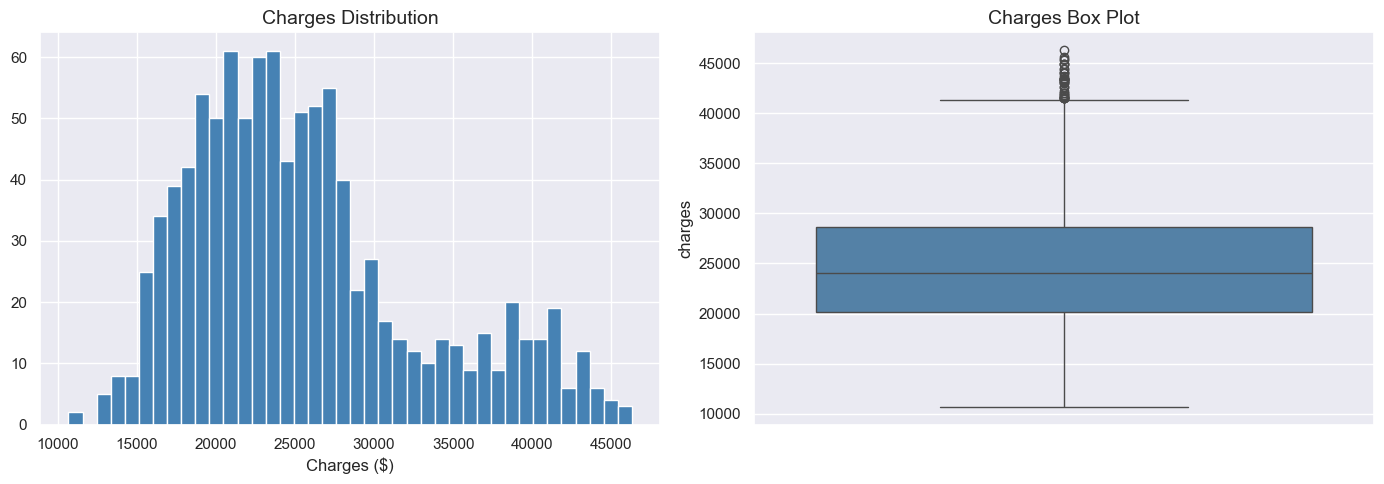

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Charges Distribution', fontsize=14)
axes[0].set_xlabel('Charges ($)')
sns.boxplot(y=df['charges'], ax=axes[1], color='steelblue')
axes[1].set_title('Charges Box Plot', fontsize=14)
plt.tight_layout()
plt.show()

## Numerical Feature Distributions

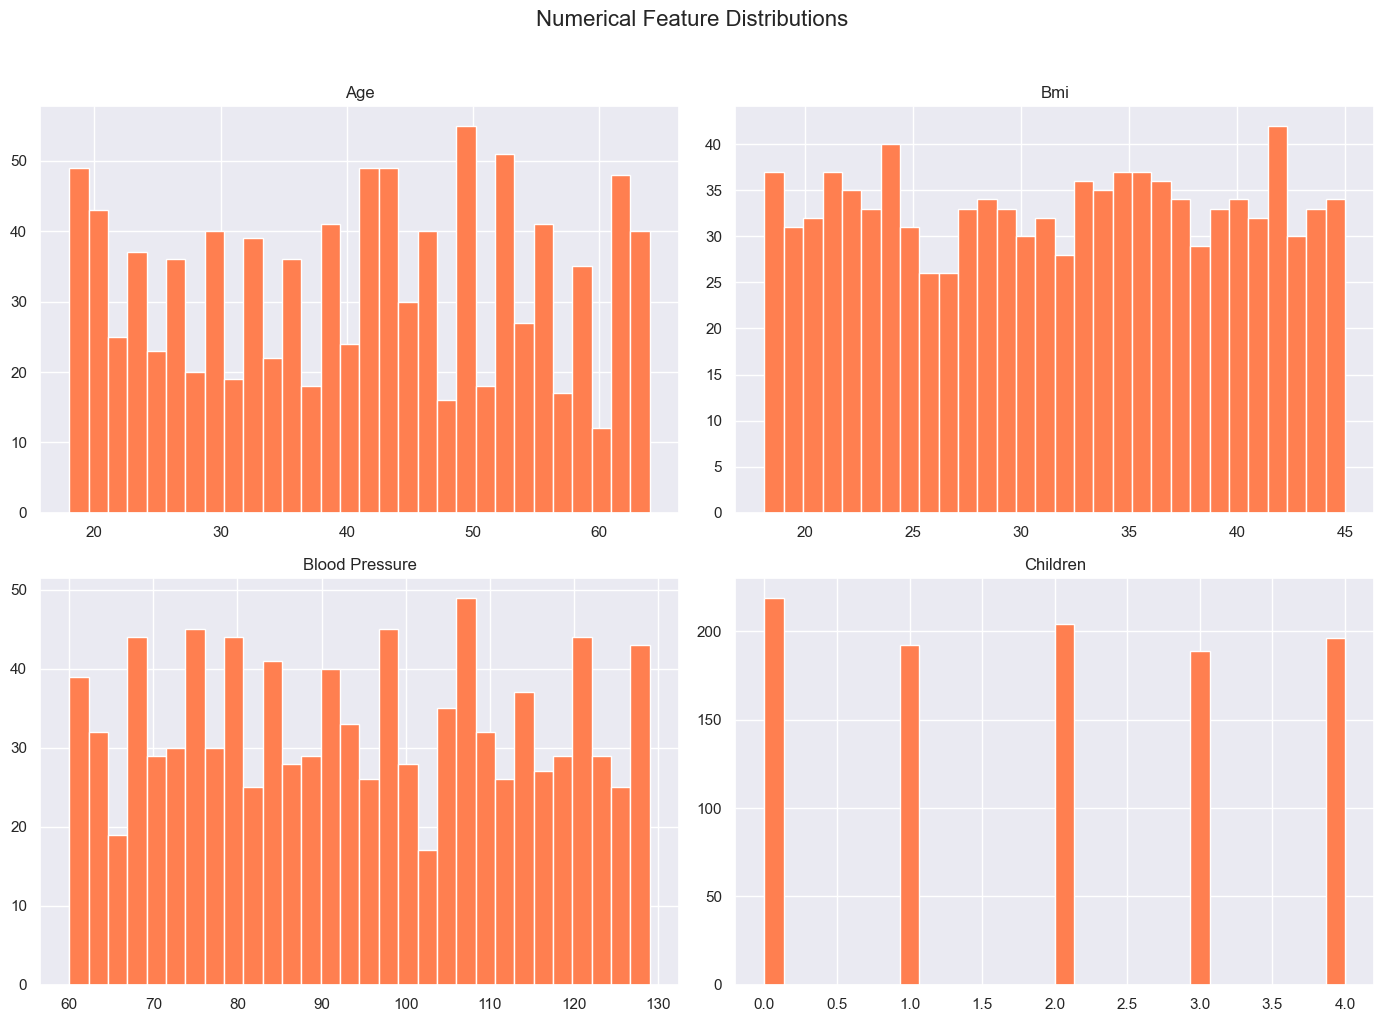

In [5]:
num_cols = ['age', 'bmi', 'blood_pressure', 'children']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=30, color='coral', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=12)
plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Heatmap

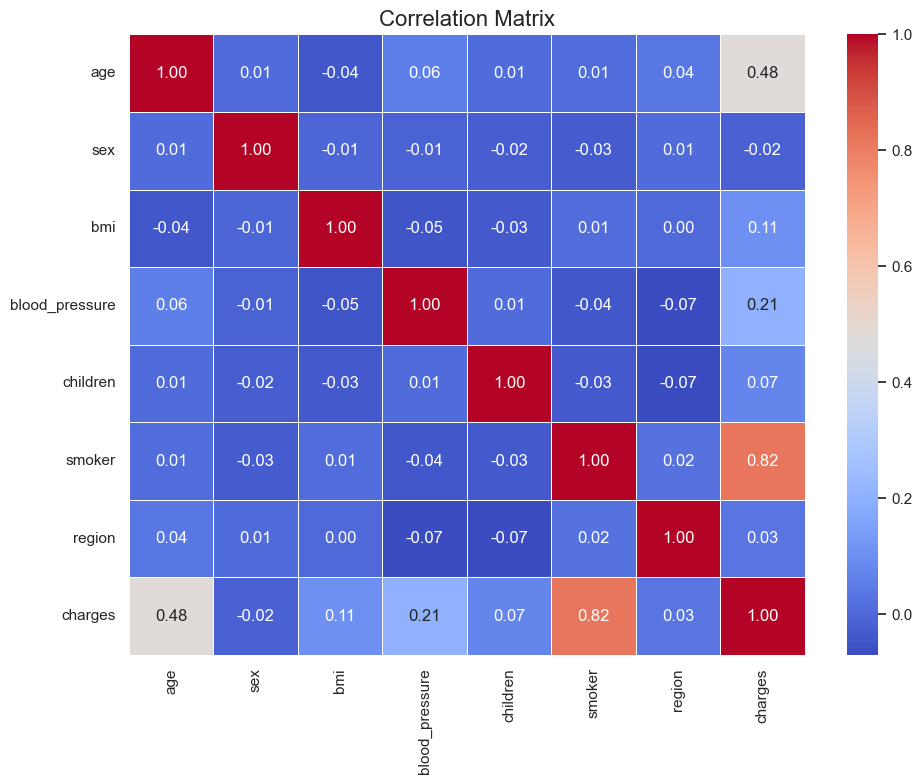

In [6]:
from sklearn.preprocessing import LabelEncoder
df_enc = df.copy()
for col in ['sex', 'region']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

## Smoker vs Charges

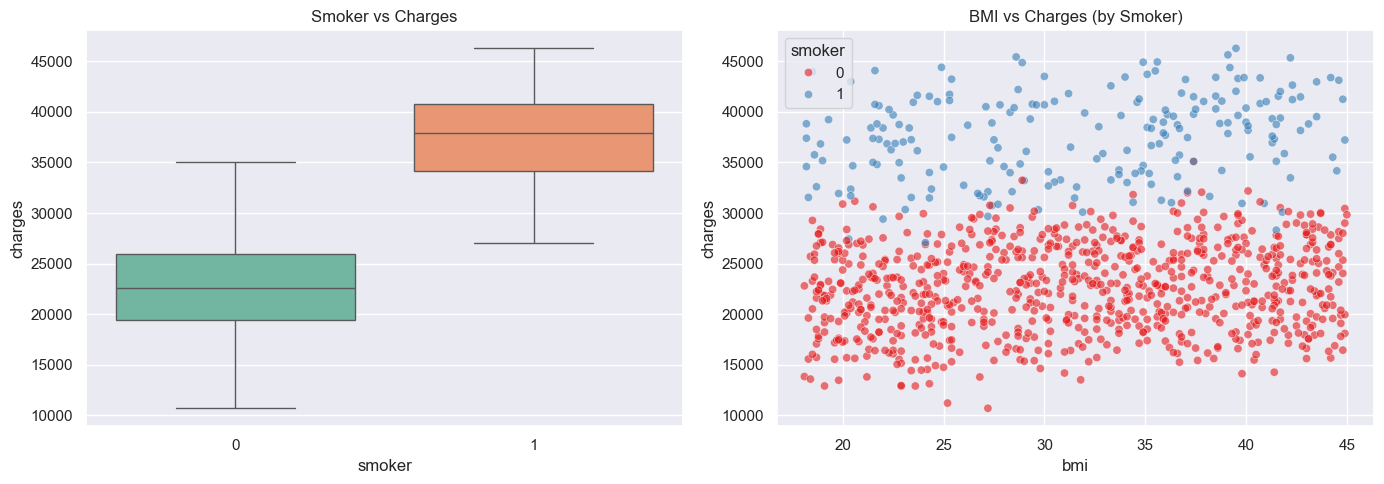

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Smoker vs Charges')
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1], palette='Set1', alpha=0.6)
axes[1].set_title('BMI vs Charges (by Smoker)')
plt.tight_layout()
plt.show()

## Region Analysis

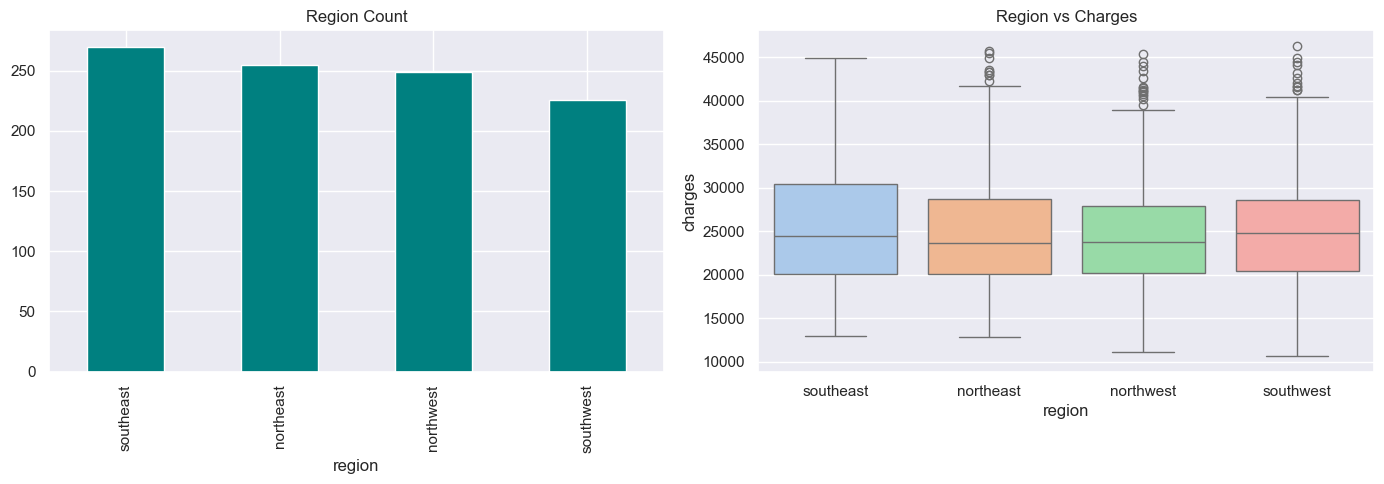

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['region'].value_counts().plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Region Count')
sns.boxplot(x='region', y='charges', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Region vs Charges')
plt.tight_layout()
plt.show()

## AdaBoost Model Training & Evaluation

In [9]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_m = df.copy()
df_m['sex'] = LabelEncoder().fit_transform(df_m['sex'])
df_m['region'] = LabelEncoder().fit_transform(df_m['region'])

X = df_m.drop('charges', axis=1)
y = df_m['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

model = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                           n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

print(f'R²   : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):.2f}')

R²   : 0.9249
RMSE : 2122.04
MAE  : 1729.09


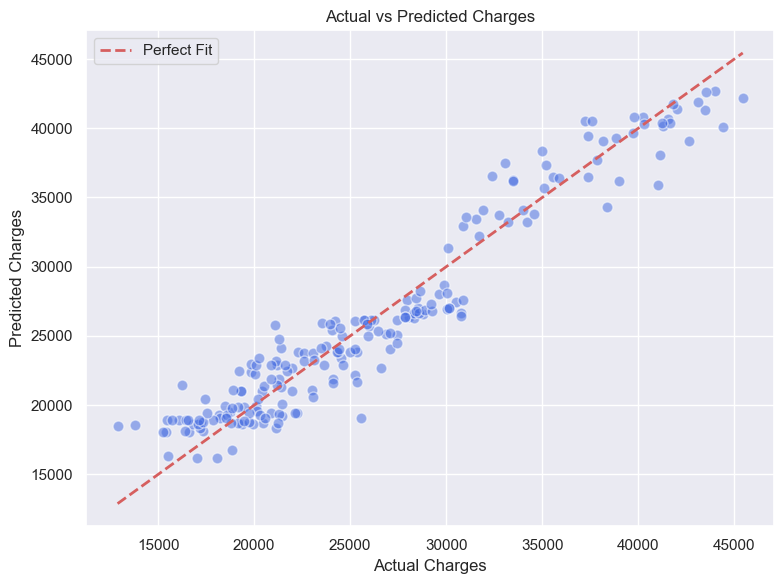

In [10]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', edgecolors='white', s=60)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.legend()
plt.tight_layout()
plt.show()

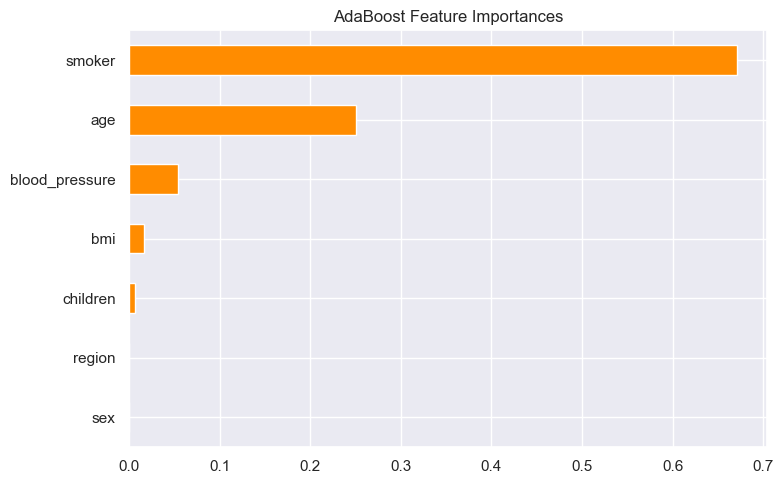

In [11]:
# Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='darkorange', figsize=(8, 5))
plt.title('AdaBoost Feature Importances')
plt.tight_layout()
plt.show()